# LSTM Emotion Classifier

Phân loại cảm xúc văn bản sử dụng mô hình LSTM.

**Dataset:** 6 nhãn cảm xúc — sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)

| Split | Samples |
|-------|--------:|
| Train | 16,000 |
| Val   |  2,000 |
| Test  |  2,000 |

## 1. Import & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
from sklearn.metrics import classification_report, confusion_matrix

# Config
SEED = 42
VOCAB_SIZE = 20000
MAX_LEN = 128
EMBED_DIM = 100
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3
BATCH_SIZE = 64
LR = 1e-3
EMBED_LR = 1e-4          # Embedding học chậm hơn 10x → adapt mà không overfit
EPOCHS = 15
NUM_CLASSES = 6
WORD_DROP = 0.0          # Không cần nữa: vocab 400K → OOV gần như 0
EARLY_STOP_PATIENCE = 4
GLOVE_PATH = "glove.6B.100d.txt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


## 2. Load Data

In [2]:
df_train = pd.read_csv("emotion_train_augmented_v3.csv")
df_val = pd.read_csv("emotion_val.csv")
df_test = pd.read_csv("emotion_test.csv")

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
df_train.head()

Train: 16518, Val: 2000, Test: 2000


,text,label
0,i feel empty when the baby isnt there,0
1,i feel really lucky for everything i have this...,1
2,ive somehow had a few epiphanies and toned dow...,2
3,i be think she just rolled out i guess she s o...,5
4,i feel like i should give it a shout out becau...,1


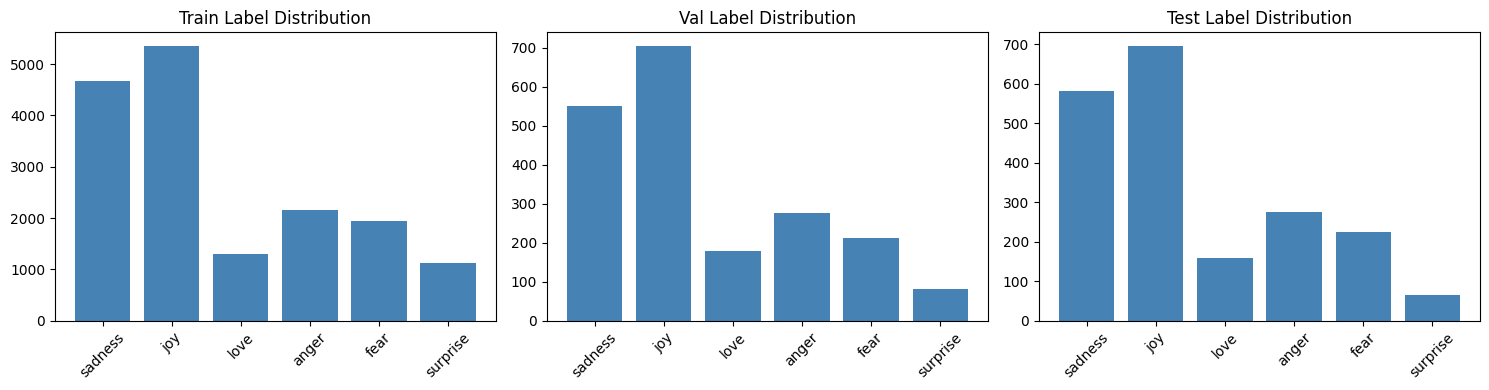

In [3]:
LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df["label"].value_counts().sort_index()
    ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values, color="steelblue")
    ax.set_title(f"{name} Label Distribution")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Tokenizer & Vocabulary

In [4]:
# Contraction map — apostrophe bị strip nên "can't" → "cant" (OOV/low GloVe quality)
# Expand về dạng đầy đủ để dùng được GloVe vectors chất lượng cao hơn
CONTRACTIONS = {
    "dont":    "do not",    "doesnt":  "does not",  "didnt":   "did not",
    "cant":    "can not",   "couldnt": "could not",  "wont":    "will not",
    "wouldnt": "would not", "shouldnt":"should not", "mustnt":  "must not",
    "im":      "i am",      "ive":     "i have",     "ill":     "i will",
    "youre":   "you are",   "youve":   "you have",   "youll":   "you will",
    "hes":     "he is",     "shes":    "she is",
    "theyre":  "they are",  "theyve":  "they have",  "theyll":  "they will",
    "weve":    "we have",   "isnt":    "is not",     "arent":   "are not",
    "wasnt":   "was not",   "werent":  "were not",   "havent":  "have not",
    "hasnt":   "has not",   "hadnt":   "had not",
}

def tokenize(text):
    """Lowercase → strip punctuation → expand contractions → split."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()
    expanded = []
    for t in tokens:
        expanded.extend(CONTRACTIONS.get(t, t).split())
    return expanded

# Build vocabulary from training data
counter = Counter()
for text in df_train["text"]:
    counter.update(tokenize(str(text)))

# Special tokens: <pad>=0, <unk>=1
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {list(vocab.items())[:10]}")

# Demo contraction expansion
print("\nContraction expansion demo:")
for s in ["i cant sleep", "im feeling scared", "dont worry"]:
    print(f"  '{s}' → {tokenize(s)}")

Vocabulary size: 15187
Sample tokens: [('<pad>', 0), ('<unk>', 1), ('i', 2), ('feel', 3), ('and', 4), ('to', 5), ('the', 6), ('a', 7), ('that', 8), ('feeling', 9)]

Contraction expansion demo:
  'i cant sleep' → ['i', 'can', 'not', 'sleep']
  'im feeling scared' → ['i', 'am', 'feeling', 'scared']
  'dont worry' → ['do', 'not', 'worry']


In [5]:
# === Load GloVe ===
def load_glove(path):
    embeddings = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings

glove = load_glove(GLOVE_PATH)
print(f"Loaded {len(glove):,} GloVe vectors (dim={EMBED_DIM})")

# === Mở rộng vocab: training words + toàn bộ GloVe words ===
# Vấn đề gốc: "scary", "wow", "lonely"... không có trong training vocab → OOV → <unk>
# Fix: thêm tất cả GloVe words vào vocab → inference-time OOV hầu như không còn
train_vocab_size = len(vocab)
for word in glove:
    if word not in vocab:
        vocab[word] = len(vocab)

glove_only_count = len(vocab) - train_vocab_size
print(f"\nVocab size: {train_vocab_size:,} (training) + {glove_only_count:,} (GloVe-only) = {len(vocab):,} total")

# === Build embedding matrix ===
embedding_matrix = np.zeros((len(vocab), EMBED_DIM), dtype=np.float32)
found = 0
for word, idx in vocab.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1
    elif word != "<pad>":
        embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, EMBED_DIM)

embedding_matrix[vocab["<unk>"]] = np.mean(np.stack(list(glove.values())), axis=0)
print(f"GloVe coverage: {found}/{len(vocab)} ({100*found/len(vocab):.1f}%)")

embedding_tensor = torch.from_numpy(embedding_matrix)
print(f"Embedding matrix: {embedding_tensor.shape}")

# === OOV check với extended vocab ===
print("\n=== OOV check với extended vocab ===")
sample_sentences = [
    "i feel so happy and grateful today",
    "i am really angry about what happened",
    "this is so scary i cant sleep",
    "i feel so sad and lonely",
    "i love you so much",
    "wow i did not expect that at all",
]
any_oov = False
for s in sample_sentences:
    tokens = tokenize(s)
    oov = [t for t in tokens if t not in vocab]
    if oov:
        print(f'  "{s}" → OOV: {oov}')
        any_oov = True
if not any_oov:
    print("  Tất cả tokens đều được cover — không còn OOV!")

Loaded 400,000 GloVe vectors (dim=100)

Vocab size: 15,187 (training) + 385,809 (GloVe-only) = 400,996 total
GloVe coverage: 400000/400996 (99.8%)
Embedding matrix: torch.Size([400996, 100])

=== OOV check với extended vocab ===
  Tất cả tokens đều được cover — không còn OOV!


In [6]:
# ── Lưu Vocabulary ra disk ─────────────────────────────────────────────────
# Vocab cuối = training words + toàn bộ GloVe → phải khớp embedding.weight shape
# Phải chạy cell này TRƯỚC khi dùng web demo (inference server cần file này)

import pickle, pathlib

_ARTIFACTS_DIR = pathlib.Path("../../models/text_dataset")
_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

vocab_path = _ARTIFACTS_DIR / "lstm_vocab.pkl"
with open(vocab_path, "wb") as f:
    pickle.dump(vocab, f)

print(f"✅  Vocab saved → {vocab_path.resolve()}")
print(f"    Vocab size  : {len(vocab):,} tokens")
print(f"    <pad>=0, <unk>=1 | training={train_vocab_size:,} | GloVe-only={glove_only_count:,}")


✅  Vocab saved → D:\HCMUT 2023\K252\models\text_dataset\lstm_vocab.pkl
    Vocab size  : 400,996 tokens
    <pad>=0, <unk>=1 | training=15,187 | GloVe-only=385,809


In [7]:
def encode(text, vocab, max_len):
    """Tokenize and convert to padded index sequence."""
    tokens = tokenize(str(text))
    indices = [vocab.get(t, vocab["<unk>"]) for t in tokens[:max_len]]
    # Pad
    indices += [vocab["<pad>"]] * (max_len - len(indices))
    return indices

# Test
sample = df_train["text"].iloc[0]
print(f"Text: {sample}")
print(f"Encoded (first 20): {encode(sample, vocab, MAX_LEN)[:20]}")

Text: i feel empty when the baby isnt there
Encoded (first 20): [2, 3, 493, 34, 6, 465, 21, 14, 80, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 4. Dataset & DataLoader

In [8]:
class EmotionDataset(Dataset):
    def __init__(self, df, vocab, max_len, word_drop=0.0):
        self.texts = df["text"].values
        self.labels = df["label"].values
        self.vocab = vocab
        self.max_len = max_len
        self.word_drop = word_drop
        self.unk_idx = vocab["<unk>"]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        # Word dropout: randomly replace tokens with <unk> → model học được embedding <unk> có nghĩa
        if self.word_drop > 0:
            mask = (torch.rand(len(x)) < self.word_drop) & (x != 0)  # không drop <pad>
            x[mask] = self.unk_idx
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_ds = EmotionDataset(df_train, vocab, MAX_LEN, word_drop=WORD_DROP)
val_ds   = EmotionDataset(df_val,   vocab, MAX_LEN)
test_ds  = EmotionDataset(df_test,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

x_batch, y_batch = next(iter(train_loader))
print(f"Batch x: {x_batch.shape}, y: {y_batch.shape}")

Batch x: torch.Size([64, 128]), y: torch.Size([64])


## 5. LSTM Model

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout,
                 pad_idx=0, pretrained_embeddings=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings.float())
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)

def create_model():
    """Create a fresh LSTM model with pretrained GloVe embeddings."""
    model = LSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
        pretrained_embeddings=embedding_tensor,
    ).to(DEVICE)
    return model

model = create_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(model)

Trainable params: 42,412,822 / 42,412,822 (100.0%)
LSTMClassifier(
  (embedding): Embedding(400996, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)


## 6. Training Utilities

In [10]:
import time

# Sqrt class weights — nhe hon inverse frequency, tranh bias qua manh ve minority
# sqrt(inverse freq) thay vi inverse freq de giam chenh lech giua majority va minority
class_counts = df_train["label"].value_counts().sort_index().values
class_weights = 1.0 / np.sqrt(class_counts.astype(float))
class_weights = torch.tensor(class_weights / class_weights.sum() * NUM_CLASSES, dtype=torch.float)
print(f"Class weights (sqrt): { {LABEL_NAMES[i]: f'{w:.3f}' for i, w in enumerate(class_weights)} }")

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def get_predictions(model, loader):
    """Collect all predictions and labels from a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            preds = model(x).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

def run_experiment(strategy_name, model, optimizer, epochs=EPOCHS, patience=EARLY_STOP_PATIENCE):
    """Train model with given optimizer and return results dict."""
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    no_improve = 0
    best_state = None

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*65}")
    print(f"  Strategy: {strategy_name}")
    print(f"  Trainable params: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")
    print(f"{'='*65}")

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " *"
        else:
            no_improve += 1
            marker = ""

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{marker}"
        )

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    train_time = time.time() - start_time

    # Load best model and evaluate on test set
    model.load_state_dict(best_state)
    model.to(DEVICE)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    labels, preds = get_predictions(model, test_loader)

    report = classification_report(labels, preds, target_names=LABEL_NAMES, digits=4, output_dict=True)

    print(f"\n>>> Test Accuracy: {test_acc:.4f} | Macro F1: {report['macro avg']['f1-score']:.4f} | Time: {train_time:.1f}s")
    print(classification_report(labels, preds, target_names=LABEL_NAMES, digits=4))

    return {
        "name": strategy_name,
        "model": model,
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "train_time": train_time,
        "labels": labels,
        "preds": preds,
        "report": report,
        "best_val_loss": best_val_loss,
    }

results = {}  # Store results for all strategies

Class weights (sqrt): {'sadness': '0.674', 'joy': '0.630', 'love': '1.278', 'anger': '0.992', 'fear': '1.048', 'surprise': '1.378'}


## 7. Strategy 1 — Freeze Backbone (Đóng băng mạng xương sống)

Đóng băng Embedding + LSTM, chỉ huấn luyện lớp FC (classifier head).

- **Ưu điểm:** Nhanh, ít tham số cần học, tránh overfitting trên dữ liệu nhỏ.
- **Nhược điểm:** Backbone không thích nghi được với domain cụ thể.

In [11]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s1 = create_model()

# Freeze embedding + LSTM (backbone) → chỉ train FC head
for param in model_s1.embedding.parameters():
    param.requires_grad = False
for param in model_s1.lstm.parameters():
    param.requires_grad = False

optimizer_s1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_s1.parameters()),
    lr=LR, weight_decay=1e-4,
)

results["freeze"] = run_experiment("Freeze Backbone", model_s1, optimizer_s1)


  Strategy: Freeze Backbone
  Trainable params: 3,078 / 42,412,822 (0.0%)
Epoch 01/15 | Train Loss: 1.7480 Acc: 0.3202 | Val Loss: 1.7217 Acc: 0.3520 *
Epoch 02/15 | Train Loss: 1.7432 Acc: 0.3285 | Val Loss: 1.7242 Acc: 0.3520
Epoch 03/15 | Train Loss: 1.7412 Acc: 0.3371 | Val Loss: 1.7200 Acc: 0.3695 *
Epoch 04/15 | Train Loss: 1.7398 Acc: 0.3397 | Val Loss: 1.7187 Acc: 0.3995 *
Epoch 05/15 | Train Loss: 1.7377 Acc: 0.3494 | Val Loss: 1.7192 Acc: 0.3580
Epoch 06/15 | Train Loss: 1.7366 Acc: 0.3467 | Val Loss: 1.7125 Acc: 0.3840 *
Epoch 07/15 | Train Loss: 1.7351 Acc: 0.3535 | Val Loss: 1.7113 Acc: 0.3960 *
Epoch 08/15 | Train Loss: 1.7327 Acc: 0.3543 | Val Loss: 1.7134 Acc: 0.3870
Epoch 09/15 | Train Loss: 1.7334 Acc: 0.3508 | Val Loss: 1.7110 Acc: 0.4040 *
Epoch 10/15 | Train Loss: 1.7307 Acc: 0.3517 | Val Loss: 1.7063 Acc: 0.4005 *
Epoch 11/15 | Train Loss: 1.7301 Acc: 0.3570 | Val Loss: 1.7058 Acc: 0.3915 *
Epoch 12/15 | Train Loss: 1.7296 Acc: 0.3531 | Val Loss: 1.7069 Acc: 0.40

d:\HCMUT 2023\K252\DL\BTL1\zvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\HCMUT 2023\K252\DL\BTL1\zvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\HCMUT 2023\K252\DL\BTL1\zvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\H

## 8. Strategy 2 — Full Fine-tune (Tinh chỉnh toàn bộ)

Tất cả tham số (Embedding + LSTM + FC) đều được huấn luyện với cùng learning rate.

- **Ưu điểm:** Toàn bộ mô hình thích nghi với dữ liệu mới.
- **Nhược điểm:** Dễ overfitting với dữ liệu nhỏ, embedding pretrained có thể bị phá hỏng.

In [12]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s2 = create_model()

# Full fine-tune: tất cả params cùng learning rate
optimizer_s2 = torch.optim.Adam(model_s2.parameters(), lr=LR, weight_decay=1e-4)

results["full"] = run_experiment("Full Fine-tune", model_s2, optimizer_s2)


  Strategy: Full Fine-tune
  Trainable params: 42,412,822 / 42,412,822 (100.0%)
Epoch 01/15 | Train Loss: 1.5255 Acc: 0.4528 | Val Loss: 1.1247 Acc: 0.5735 *
Epoch 02/15 | Train Loss: 0.8421 Acc: 0.7212 | Val Loss: 0.5489 Acc: 0.8315 *
Epoch 03/15 | Train Loss: 0.4376 Acc: 0.8567 | Val Loss: 0.2819 Acc: 0.9020 *
Epoch 04/15 | Train Loss: 0.2882 Acc: 0.9094 | Val Loss: 0.2313 Acc: 0.9185 *
Epoch 05/15 | Train Loss: 0.2192 Acc: 0.9241 | Val Loss: 0.1949 Acc: 0.9230 *
Epoch 06/15 | Train Loss: 0.1743 Acc: 0.9387 | Val Loss: 0.1845 Acc: 0.9310 *
Epoch 07/15 | Train Loss: 0.1511 Acc: 0.9465 | Val Loss: 0.1827 Acc: 0.9235 *
Epoch 08/15 | Train Loss: 0.1253 Acc: 0.9576 | Val Loss: 0.1743 Acc: 0.9290 *
Epoch 09/15 | Train Loss: 0.1085 Acc: 0.9626 | Val Loss: 0.2100 Acc: 0.9320
Epoch 10/15 | Train Loss: 0.0901 Acc: 0.9686 | Val Loss: 0.2451 Acc: 0.9315
Epoch 11/15 | Train Loss: 0.0819 Acc: 0.9725 | Val Loss: 0.2118 Acc: 0.9320
Epoch 12/15 | Train Loss: 0.0591 Acc: 0.9807 | Val Loss: 0.2376 Acc

## 9. Strategy 3 — Layer-wise Learning Rate (Tốc độ học theo từng tầng)

Mỗi nhóm tầng có learning rate riêng:
- **Embedding:** LR thấp (1e-4) — giữ tri thức GloVe, chỉ adapt nhẹ.
- **LSTM:** LR trung bình (1e-3) — học biểu diễn ngữ cảnh cho task.
- **FC:** LR trung bình (1e-3) — classifier head.

Đây là chiến lược cân bằng giữa freeze và full fine-tune.

In [13]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s3 = create_model()

# Layer-wise LR: embedding học chậm hơn 10x → adapt mà không overfit
optimizer_s3 = torch.optim.Adam([
    {"params": model_s3.embedding.parameters(), "lr": EMBED_LR},   # 1e-4
    {"params": model_s3.lstm.parameters(),      "lr": LR},          # 1e-3
    {"params": model_s3.fc.parameters(),        "lr": LR},          # 1e-3
], weight_decay=1e-4)

results["layerwise"] = run_experiment("Layer-wise LR", model_s3, optimizer_s3)


  Strategy: Layer-wise LR
  Trainable params: 42,412,822 / 42,412,822 (100.0%)
Epoch 01/15 | Train Loss: 1.5777 Acc: 0.4398 | Val Loss: 1.2604 Acc: 0.5560 *
Epoch 02/15 | Train Loss: 1.0995 Acc: 0.6201 | Val Loss: 0.8008 Acc: 0.7375 *
Epoch 03/15 | Train Loss: 0.7985 Acc: 0.7279 | Val Loss: 0.5217 Acc: 0.8175 *
Epoch 04/15 | Train Loss: 0.6270 Acc: 0.7850 | Val Loss: 0.4187 Acc: 0.8560 *
Epoch 05/15 | Train Loss: 0.5111 Acc: 0.8243 | Val Loss: 0.3278 Acc: 0.8835 *
Epoch 06/15 | Train Loss: 0.4289 Acc: 0.8459 | Val Loss: 0.2825 Acc: 0.8910 *
Epoch 07/15 | Train Loss: 0.3783 Acc: 0.8684 | Val Loss: 0.2530 Acc: 0.9065 *
Epoch 08/15 | Train Loss: 0.3270 Acc: 0.8838 | Val Loss: 0.2266 Acc: 0.9035 *
Epoch 09/15 | Train Loss: 0.2958 Acc: 0.8928 | Val Loss: 0.1967 Acc: 0.9210 *
Epoch 10/15 | Train Loss: 0.2628 Acc: 0.9008 | Val Loss: 0.1857 Acc: 0.9220 *
Epoch 11/15 | Train Loss: 0.2497 Acc: 0.9062 | Val Loss: 0.1804 Acc: 0.9235 *
Epoch 12/15 | Train Loss: 0.2338 Acc: 0.9123 | Val Loss: 0.159

## 10. So sánh kết quả (Results Comparison)

  LSTM Fine-tuning Strategy Comparison
       Strategy Test Accuracy Macro F1 Weighted F1 Train Time (s) Best Val Loss
Freeze Backbone        0.4105   0.1584      0.3081           90.3        1.7020
 Full Fine-tune        0.9240   0.8869      0.9264          230.3        0.1743
  Layer-wise LR        0.9215   0.8830      0.9239          293.7        0.1463



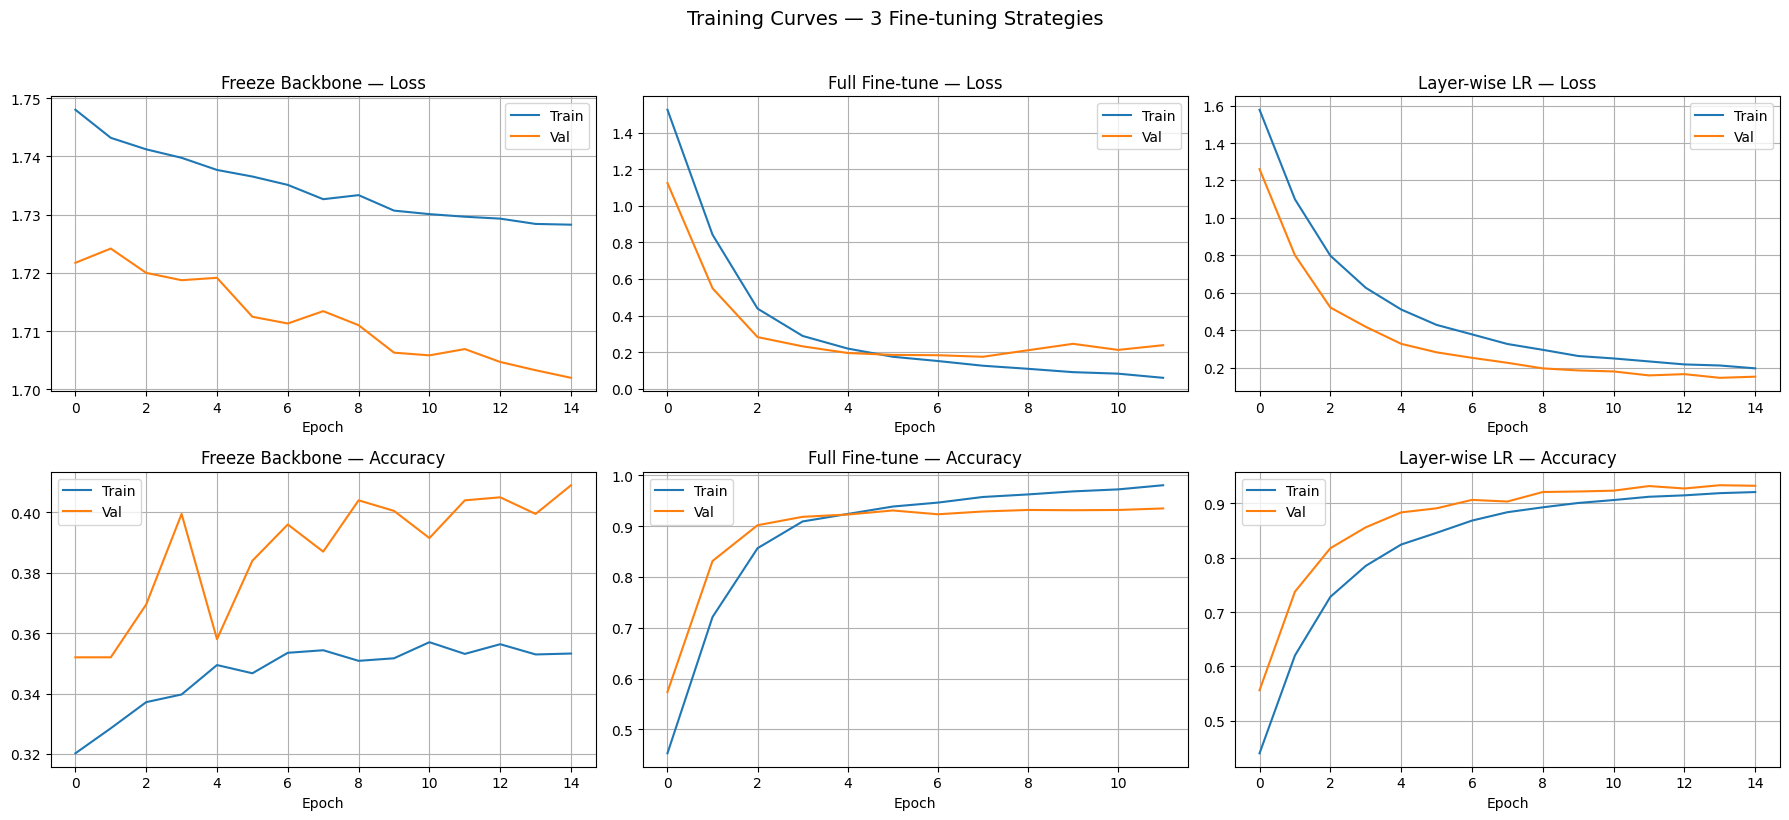

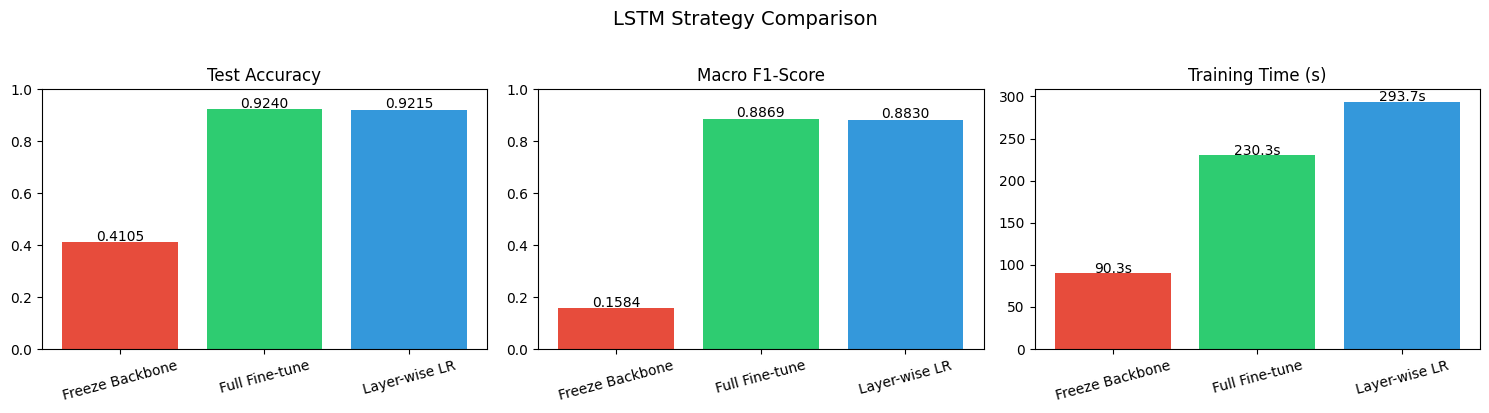

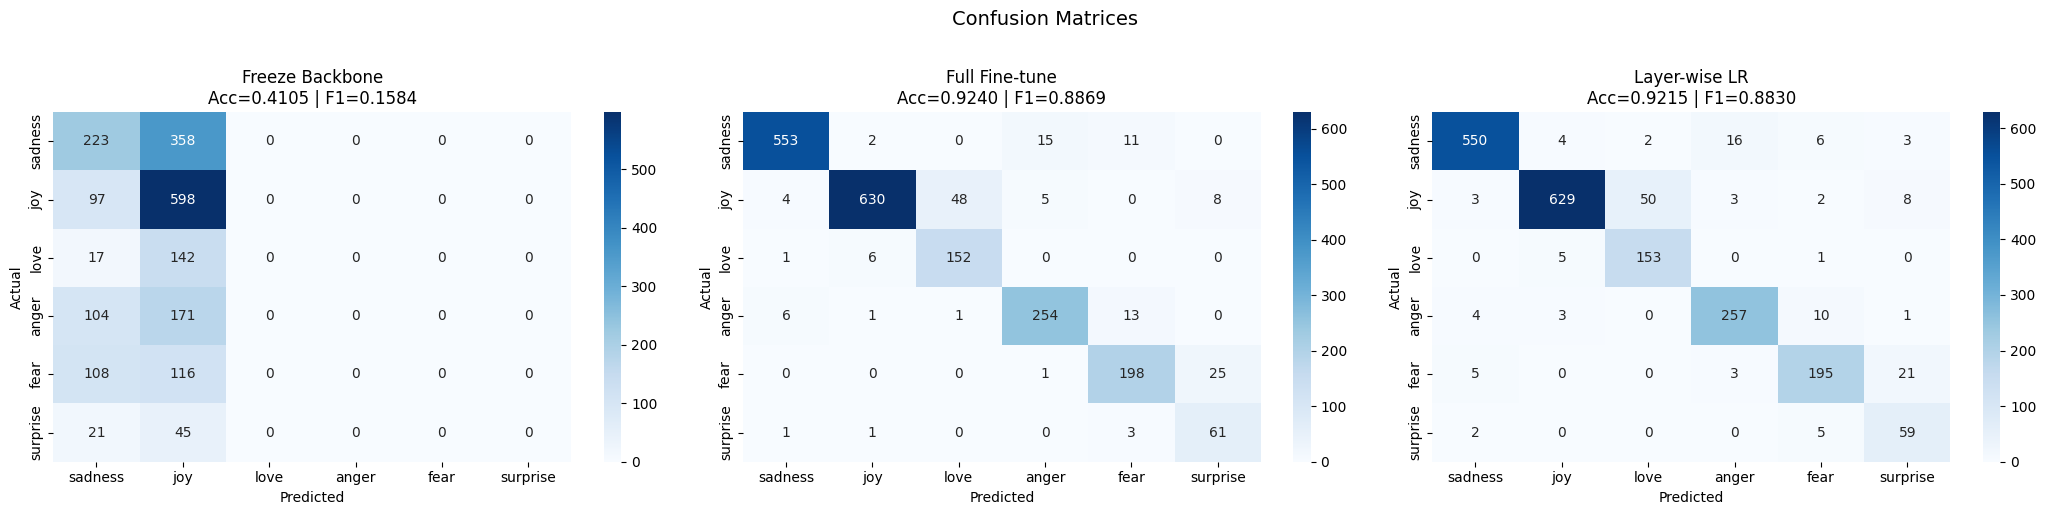


Best strategy: Full Fine-tune (Macro F1: 0.8869)
Saved best model to best_lstm_model.pt


In [14]:
# === Summary Table ===
summary = pd.DataFrame([
    {
        "Strategy": r["name"],
        "Test Accuracy": f"{r['test_acc']:.4f}",
        "Macro F1": f"{r['macro_f1']:.4f}",
        "Weighted F1": f"{r['weighted_f1']:.4f}",
        "Train Time (s)": f"{r['train_time']:.1f}",
        "Best Val Loss": f"{r['best_val_loss']:.4f}",
    }
    for r in results.values()
])
print("=" * 85)
print("  LSTM Fine-tuning Strategy Comparison")
print("=" * 85)
print(summary.to_string(index=False))
print()

# === Training Curves ===
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, (key, r) in enumerate(results.items()):
    axes[0, i].plot(r["history"]["train_loss"], label="Train")
    axes[0, i].plot(r["history"]["val_loss"], label="Val")
    axes[0, i].set_title(f'{r["name"]} — Loss')
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].legend()
    axes[0, i].grid(True)

    axes[1, i].plot(r["history"]["train_acc"], label="Train")
    axes[1, i].plot(r["history"]["val_acc"], label="Val")
    axes[1, i].set_title(f'{r["name"]} — Accuracy')
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].legend()
    axes[1, i].grid(True)
plt.suptitle("Training Curves — 3 Fine-tuning Strategies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Bar Chart Comparison ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = [r["name"] for r in results.values()]
colors = ["#e74c3c", "#2ecc71", "#3498db"]

axes[0].bar(names, [r["test_acc"] for r in results.values()], color=colors)
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0.0, 1.0)
for j, r in enumerate(results.values()):
    axes[0].text(j, r["test_acc"] + 0.005, f"{r['test_acc']:.4f}", ha="center", fontsize=10)

axes[1].bar(names, [r["macro_f1"] for r in results.values()], color=colors)
axes[1].set_title("Macro F1-Score")
axes[1].set_ylim(0.0, 1.0)
for j, r in enumerate(results.values()):
    axes[1].text(j, r["macro_f1"] + 0.005, f"{r['macro_f1']:.4f}", ha="center", fontsize=10)

axes[2].bar(names, [r["train_time"] for r in results.values()], color=colors)
axes[2].set_title("Training Time (s)")
for j, r in enumerate(results.values()):
    axes[2].text(j, r["train_time"] + 0.5, f"{r['train_time']:.1f}s", ha="center", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("LSTM Strategy Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Confusion Matrices ===
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, (key, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f'{r["name"]}\nAcc={r["test_acc"]:.4f} | F1={r["macro_f1"]:.4f}')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Save best model ===
best_key = max(results, key=lambda k: results[k]["macro_f1"])
best_result = results[best_key]
torch.save(best_result["model"].state_dict(), "best_lstm_model.pt")
print(f"\nBest strategy: {best_result['name']} (Macro F1: {best_result['macro_f1']:.4f})")
print("Saved best model to best_lstm_model.pt")

## 11. Inference (Demo)

In [15]:
def predict_emotion(text, model, vocab, max_len=MAX_LEN):
    model.eval()
    x = torch.tensor([encode(text, vocab, max_len)], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = probs.argmax()
    return LABEL_NAMES[pred], {LABEL_NAMES[i]: f"{p:.4f}" for i, p in enumerate(probs)}

# Use the best strategy model
best_model = best_result["model"]
print(f"Using best model: {best_result['name']} (Macro F1: {best_result['macro_f1']:.4f})\n")

test_sentences = [
    "i feel so happy and grateful today",
    "i am really angry about what happened",
    "this is so scary i cant sleep",
    "i feel so sad and lonely",
    "I really love her",
    "wow i did not expect that at all",
]

for s in test_sentences:
    label, probs = predict_emotion(s, best_model, vocab)
    print(f"\"{s}\"")
    print(f"  => {label} | {probs}\n")

Using best model: Full Fine-tune (Macro F1: 0.8869)

"i feel so happy and grateful today"
  => joy | {'sadness': '0.0020', 'joy': '0.9950', 'love': '0.0024', 'anger': '0.0001', 'fear': '0.0001', 'surprise': '0.0005'}

"i am really angry about what happened"
  => anger | {'sadness': '0.0017', 'joy': '0.0002', 'love': '0.0005', 'anger': '0.9880', 'fear': '0.0085', 'surprise': '0.0011'}

"this is so scary i cant sleep"
  => fear | {'sadness': '0.1741', 'joy': '0.0845', 'love': '0.0260', 'anger': '0.1740', 'fear': '0.4087', 'surprise': '0.1328'}

"i feel so sad and lonely"
  => sadness | {'sadness': '0.9991', 'joy': '0.0001', 'love': '0.0000', 'anger': '0.0002', 'fear': '0.0005', 'surprise': '0.0000'}

"I really love her"
  => surprise | {'sadness': '0.1692', 'joy': '0.1703', 'love': '0.0235', 'anger': '0.1992', 'fear': '0.2143', 'surprise': '0.2236'}

"wow i did not expect that at all"
  => fear | {'sadness': '0.0657', 'joy': '0.1366', 'love': '0.0211', 'anger': '0.1614', 'fear': '0.3677'

## 12. Lưu Artifacts (Model + Vocab)

Lưu model tốt nhất và vocab ra `models/text_dataset/` để inference server có thể load.


In [18]:
import pickle, pathlib, torch

_ARTIFACTS_DIR = pathlib.Path("../../models/text_dataset")
_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Chọn model tốt nhất theo Macro F1
best_result = max(results.values(), key=lambda r: r["macro_f1"])
print(f"Best strategy  : {best_result['name']}")
print(f"Macro F1       : {best_result['macro_f1']:.4f}")
print(f"Test Accuracy  : {best_result['test_acc']:.4f}")

# Lưu state_dict
model_path = _ARTIFACTS_DIR / "best_lstm_model.pt"
torch.save(best_result["model"].state_dict(), model_path)
print(f"\n✅  Model saved → {model_path.resolve()}")
print(f"    Architecture : BiLSTM  embed={len(vocab):,}×{EMBED_DIM}  hidden={HIDDEN_DIM}  layers={NUM_LAYERS}")

# Refresh vocab (đảm bảo luôn khớp model vừa lưu)
vocab_path = _ARTIFACTS_DIR / "lstm_vocab.pkl"
with open(vocab_path, "wb") as f:
    pickle.dump(vocab, f)
print(f"✅  Vocab saved  → {vocab_path.resolve()}")
print(f"    Vocab size   : {len(vocab):,} tokens")



Best strategy  : Full Fine-tune
Macro F1       : 0.8869
Test Accuracy  : 0.9240

✅  Model saved → D:\HCMUT 2023\K252\models\text_dataset\best_lstm_model.pt
    Architecture : BiLSTM  embed=400,996×100  hidden=256  layers=2
✅  Vocab saved  → D:\HCMUT 2023\K252\models\text_dataset\lstm_vocab.pkl
    Vocab size   : 400,996 tokens
